In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [84]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

# decision tree for multioutput regression
from sklearn.datasets import make_regression
from sklearn.tree import DecisionTreeRegressor

# KNN for multioutput regression
from sklearn.datasets import make_regression
from sklearn.neighbors import KNeighborsRegressor

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from scipy.io import arff


In [85]:
data = arff.loadarff('/content/drive/MyDrive/Hasan sir/new_analysis/miyazaki94.arff')
df = pd.DataFrame(data[0])
df.head()

,ID,KLOC,SCRN,FORM,FILE,ESCRN,EFORM,EFILE,MM
0,1.0,44.2,24.0,26.0,41.0,246.0,642.0,589.0,59.5
1,2.0,59.0,34.0,30.0,28.0,651.0,447.0,1143.0,85.0
2,3.0,36.9,9.0,36.0,29.0,193.0,694.0,995.0,31.5
3,4.0,39.3,27.0,10.0,52.0,389.0,105.0,2344.0,58.9
4,5.0,48.3,21.0,22.0,20.0,241.0,371.0,2052.0,58.9


In [86]:
df.describe()

,ID,KLOC,SCRN,FORM,FILE,ESCRN,EFORM,EFILE,MM
count,48.00,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000
mean,24.50,70.791667,33.687500,22.375000,34.812500,525.604167,460.666667,1854.583333,87.475000
std,14.00,87.567795,47.236461,20.548464,53.364526,626.058040,396.816069,6398.604691,228.759743
min,1.00,6.900000,0.000000,0.000000,2.000000,0.000000,0.000000,57.000000,5.600000
25%,12.75,24.825000,9.000000,9.000000,11.500000,127.250000,180.500000,480.750000,26.375000
50%,24.50,45.400000,23.500000,16.000000,24.500000,322.500000,342.500000,872.500000,38.100000
75%,36.25,65.300000,36.250000,31.000000,39.500000,604.250000,636.750000,1318.000000,58.950000
max,48.00,417.600000,281.000000,91.000000,370.000000,3000.000000,1566.000000,45000.000000,1586.000000


<Axes: title={'center': 'Pearson Correlation of Features'}>

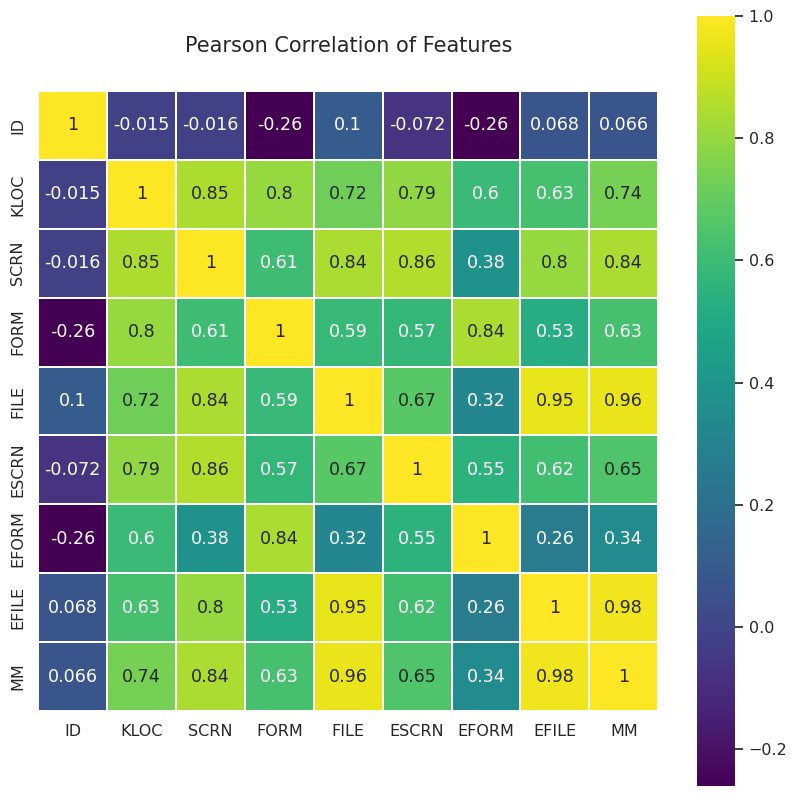

In [87]:
colormap = plt.cm.viridis
plt.figure(figsize=(10,10))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sns.set(font_scale=1.05)
sns.heatmap(df.astype(float).corr(),linewidths=0.1,vmax=1.0, square=True,cmap=colormap, linecolor='white', annot=True)

In [88]:
# map features to their absolute correlation values
corr = df.corr().abs()

# set equality (self correlation) as zero
corr[corr == 1] = 0

# of each feature, find the max correlation
# and sort the resulting array in ascending order
corr_cols = corr.max().sort_values(ascending=False)

# display the highly correlated fe
#corr_cols

# display the highly correlated features
display(corr_cols[corr_cols > 0.6])

EFILE    0.975164
MM       0.975164
FILE     0.958175
SCRN     0.856816
ESCRN    0.856816
KLOC     0.845314
FORM     0.840370
EFORM    0.840370
dtype: float64

In [46]:
#features = [ 'TeamExp', 'ManagerExp', 'YearEnd', 'Length', 'Transactions', 'Entities','PointsNonAdjust', 'Adjustment', 'PointsAjust']

max_corr_features = ['EFILE', 'MM', 'FILE','SCRN','ESCRN', 'KLOC','FORM','EFORM']

X = df[max_corr_features]
y = df['EFORM']

In [89]:
# Splitting the dataset into the Training set and Test set
X_Train, X_Test, Y_Train, Y_Test = train_test_split(X, y, test_size=0.30, random_state=30)

# ***KNeighborsRegressor***

In [90]:
#KNeighborsRegressor
neigh = KNeighborsRegressor(n_neighbors=9, weights='uniform')
neigh.fit(X_Train, Y_Train)
predict_knn = neigh.predict(X_Test)
print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_knn)))
print("Mean Absolute error", mean_absolute_error(Y_Test, predict_knn))

Root mean square:  218.23292951026835
Mean Absolute error 146.35555555555555


In [91]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [92]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [93]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_knn)
mse = mean_squared_error(Y_Test, predict_knn)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_knn)
mape = mean_absolute_percentage_error(Y_Test, predict_knn)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 146.36
Mean Squared Error (MSE): 47625.61
Root Mean Squared Error (RMSE): 218.23
R-squared (R²): 0.64
mape: 52.05


In [94]:
import matplotlib.pyplot as plot
import pandas

In [95]:
# Splitting the dataset into the Training set and Test set
X_Train, X_Test, Y_Train, Y_Test = train_test_split(X, y, test_size=0.30, random_state=30)

In [96]:
Y_Train.shape

(33,)

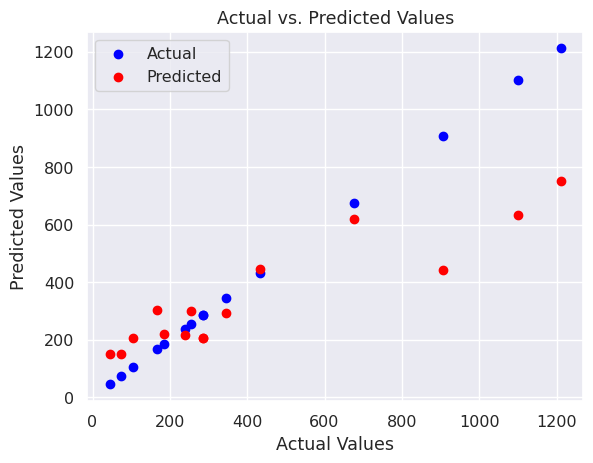

In [97]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_knn             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()

# ***LinearRegression***

In [98]:
regressor = LinearRegression()
regressor.fit(X_Train, Y_Train)
predict_LR = regressor.predict(X_Test)
print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_LR)))
print("Mean Absolute error", mean_absolute_error(Y_Test, predict_LR))

Root mean square:  2.308115806022513e-13
Mean Absolute error 1.8853067255501326e-13


In [99]:
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [100]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_LR)
mse = mean_squared_error(Y_Test, predict_LR)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_LR)
mape = mean_absolute_percentage_error(Y_Test, predict_LR)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 0.00
Mean Squared Error (MSE): 0.00
Root Mean Squared Error (RMSE): 0.00
R-squared (R²): 1.00
mape: 0.00


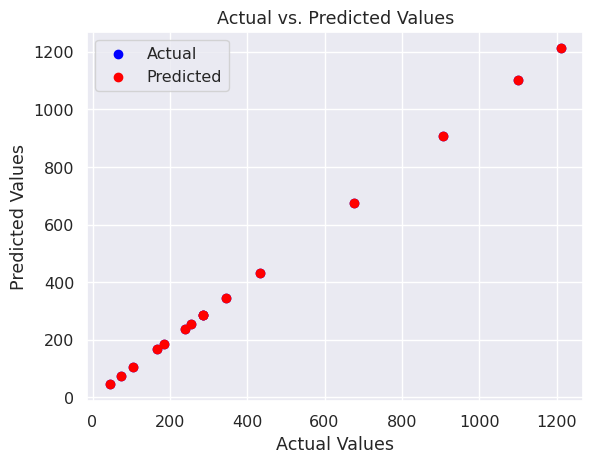

In [101]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_LR             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()

# ***RandomForestRegressor***

In [102]:
regressor = RandomForestRegressor(n_estimators=100,max_features=5)
regressor.fit(X_Train, Y_Train)
predict_RF = regressor.predict(X_Test)
print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_RF)))
print("Mean Absolute error", mean_absolute_error(Y_Test, predict_RF))

Root mean square:  41.91413031425082
Mean Absolute error 33.04799999999999


In [103]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [104]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_RF)
mse = mean_squared_error(Y_Test, predict_RF)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_RF)
mape = mean_absolute_percentage_error(Y_Test, predict_RF)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 33.05
Mean Squared Error (MSE): 1756.79
Root Mean Squared Error (RMSE): 41.91
R-squared (R²): 0.99
mape: 15.50


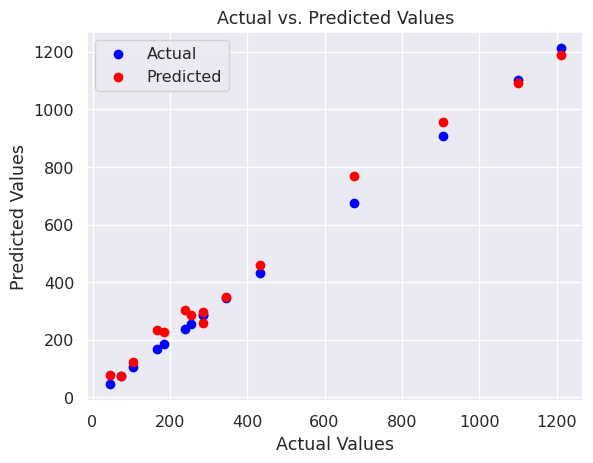

In [105]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_RF             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()

# ***SVM***

In [107]:
parameters = {'kernel':('linear', 'rbf'), 'C':[1,2,3,4,5,6,7,8,9,10, 100, 500], 'gamma':('auto', 'scale')}

svr = SVR()
LinearSVC = GridSearchCV(svr, parameters, cv=3)
LinearSVC.fit(X_Train, Y_Train)
predict_SVM = LinearSVC.predict(X_Test)
print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_SVM)))
print("Mean Absolute error", mean_absolute_error(Y_Test, predict_SVM))

Root mean square:  0.0850692626195218
Mean Absolute error 0.07631479519532482


In [108]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [109]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_SVM)
mse = mean_squared_error(Y_Test, predict_SVM)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_SVM)
mape = mean_absolute_percentage_error(Y_Test, predict_SVM)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 0.08
Mean Squared Error (MSE): 0.01
Root Mean Squared Error (RMSE): 0.09
R-squared (R²): 1.00
mape: 0.04


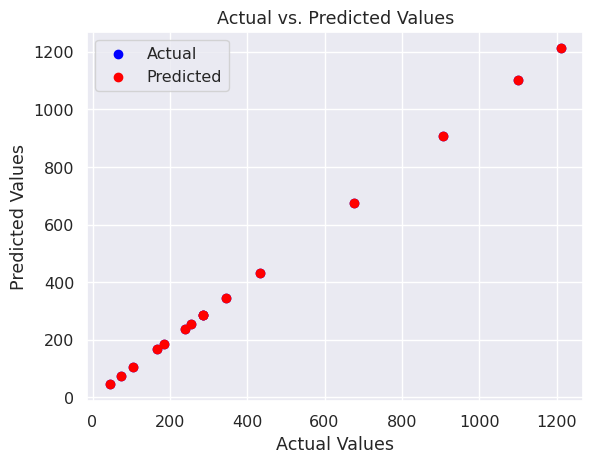

In [110]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_SVM             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()

# ***lasso***

In [75]:
from sklearn import linear_model

In [111]:
clf = linear_model.Lasso(alpha=0.1)

In [112]:
clf.fit(X_Train, Y_Train)

Lasso(alpha=0.1)

In [113]:
print(clf.coef_)

[-3.38434067e-06  7.82935042e-05  0.00000000e+00 -0.00000000e+00
  1.14606221e-05 -6.01813313e-05 -0.00000000e+00  9.99992544e-01]


In [114]:
print(clf.intercept_)

0.0006372414517272773


In [115]:
clf = linear_model.Lasso(alpha=0.1)
clf.fit(X_Train, Y_Train)
print(clf.coef_)
print(clf.intercept_)
# make a prediction
predict_LS = clf.predict(X_Test)
# summarize prediction
print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_LS)))
print("Mean Absolute error", mean_absolute_error(Y_Test, predict_LS))

[-3.38434067e-06  7.82935042e-05  0.00000000e+00 -0.00000000e+00
  1.14606221e-05 -6.01813313e-05 -0.00000000e+00  9.99992544e-01]
0.0006372414517272773
Root mean square:  0.008126166763915442
Mean Absolute error 0.0051670823344935005


In [116]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [117]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_LS)
mse = mean_squared_error(Y_Test, predict_LS)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_LS)
mape = mean_absolute_percentage_error(Y_Test, predict_LS)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 0.01
Mean Squared Error (MSE): 0.00
Root Mean Squared Error (RMSE): 0.01
R-squared (R²): 1.00
mape: 0.00


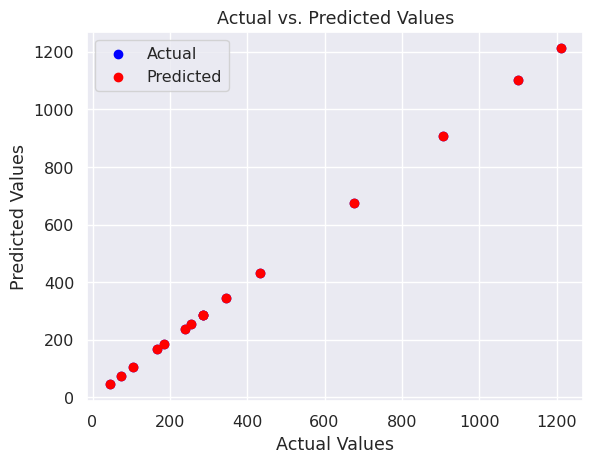

In [118]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_LS             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()